<a href="https://colab.research.google.com/github/dagudelo30/Series-de-tiempo---Javeriana-Cali/blob/main/hwt/suavización_exponencial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pronósticos basados en series de tiempo 

## Diego Fernando Agudelo
## Universidad Javeriana-Cali
## diegoagudelo30@gmail.com



## **1. Carga de paquetes**

In [1]:
import numpy as np
import pandas as pd # Operaciones con dataframes
from matplotlib import pyplot as plt # gráficos
from statsmodels.tsa.seasonal import seasonal_decompose # descomposición de series
from statsmodels.tsa.holtwinters import SimpleExpSmoothing  # Holwinters simple
from statsmodels.tsa.holtwinters import ExponentialSmoothing # Holwinters doble y tripe
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import mean_squared_error


Este documento presenta una breve introducción a la construcción de objetos de series de tiempo y el cálculo de pronósticos con modelos de suavización.

Para este ejercicio emplearemos la información disponible en el archivo datosEmpleo.xlsx. En ese archivo econtrarán la tasa de desempleo mensual de las 13 principales ciudades en Colombia (TD_13ciudades). El archivo también contiene series mensuales para las 13 principales ciudades de Colombia el número de ocupados en miles de personas (Ocupados), los desocupados (Desocupados) y los inactivos (Inactivos).

## **2. Carga de datos**

Nuestra primera tarea será leer el archivo de Excel. Para eso podemos emplear el paquete Pandas. Carguemos los datos en un objeto que denominaremos data.

In [3]:
data = pd.read_excel("https://raw.githubusercontent.com/dagudelo30/Series-de-tiempo---Javeriana-Cali/main/intro-moving_average/datosEmpleo.xlsx",index_col='mes',parse_dates=True)
data.head()

,TD_13ciudades,Ocupados,Desocupados,Inactivos
mes,,,,
2001-01-01,20.946380,6923.604,1834.507,4600.718
2001-02-01,19.894213,7037.746,1747.820,4596.805
2001-03-01,19.221565,6945.973,1652.823,4807.120
2001-04-01,17.888575,6973.079,1519.137,4937.280
2001-05-01,17.945654,6994.462,1529.720,4928.911


En este caso los datos fueron leídos como un data frame y adicionalmente la columna "mes" fue seleccionada como indice, con el dataframe de esta forma sera más facil trabajar las series de tiempo.

A continuación se gráfica la tasa de desempleo.



(222, 4)


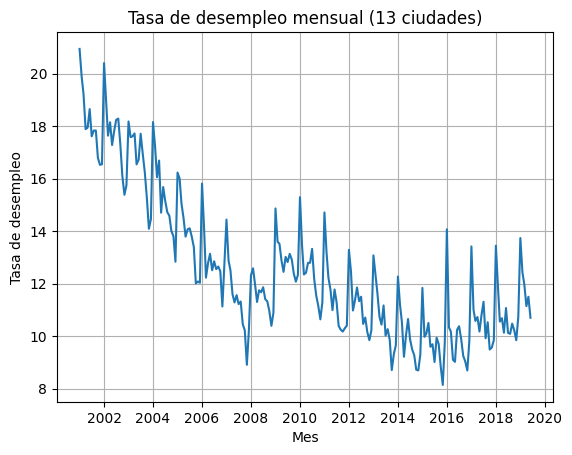

In [4]:
# imprimiendo el tamano del dataframe
print(data.shape)

# Graficando los datos
plt.title("Tasa de desempleo mensual (13 ciudades)")
plt.xlabel("Mes")
plt.ylabel("Tasa de desempleo")
plt.plot(data[["TD_13ciudades"]])
plt.grid()
plt.show()

## **3. Pronosticando metodos de suavización**

Antes de continuar es importante guardar una parte de la muestra para evaluar el comportamiento de los modelos por fuera de muestra (out-of-sample). Guardemos un año de datos.

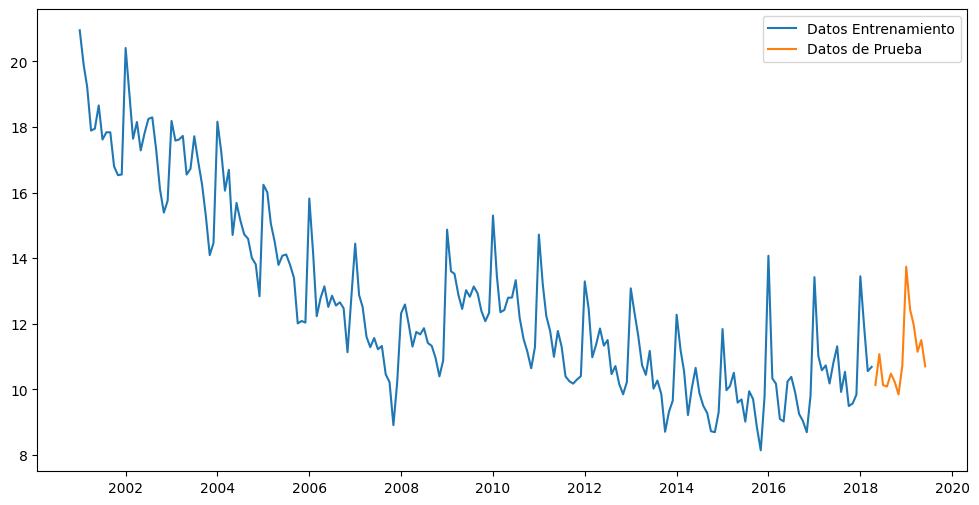

In [6]:
train_len = 208
train_td = data[["TD_13ciudades"]][:train_len]
test_td = data[["TD_13ciudades"]][train_len:]

fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(test_td,label="Datos de Prueba")
plt.legend()
plt.show()

In [7]:
train_td

,TD_13ciudades
mes,
2001-01-01,20.946380
2001-02-01,19.894213
2001-03-01,19.221565
2001-04-01,17.888575
2001-05-01,17.945654
...,...
2017-12-01,9.837395
2018-01-01,13.446245
2018-02-01,11.874973


In [8]:
test_td

,TD_13ciudades
mes,
2018-05-01,10.129211
2018-06-01,11.071347
2018-07-01,10.125100
2018-08-01,10.085244
2018-09-01,10.476567
2018-10-01,10.230811
2018-11-01,9.844539
2018-12-01,10.725865
2019-01-01,13.739328


### **3.1 Suavizacion Exponencial Simple**

In [9]:
# Build model.
ets_model = ETSModel(endog=train_td["TD_13ciudades"],error="add")#,trend="add",seasonal="mul" )
ets_result = ets_model.fit()

point_forecast=ets_result.forecast(14)

ci = ets_result.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds = pd.concat([limits, conf_forecast], axis = 1)
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds)

            Point_forecast  lower_95   upper_95
2018-05-01       10.959788  8.650409  13.269166
2018-06-01       10.959788  8.505555  13.414021
2018-07-01       10.959788  8.368785  13.550790
2018-08-01       10.959788  8.238882  13.680693
2018-09-01       10.959788  8.114905  13.804671
2018-10-01       10.959788  7.996109  13.923467
2018-11-01       10.959788  7.881895  14.037681
2018-12-01       10.959788  7.771770  14.147806
2019-01-01       10.959788  7.665324  14.254252
2019-02-01       10.959788  7.562212  14.357364
2019-03-01       10.959788  7.462138  14.457438
2019-04-01       10.959788  7.364848  14.554727
2019-05-01       10.959788  7.270124  14.649452
2019-06-01       10.959788  7.177770  14.741805


c:\Users\dagudelo\venv_ia_generativa\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


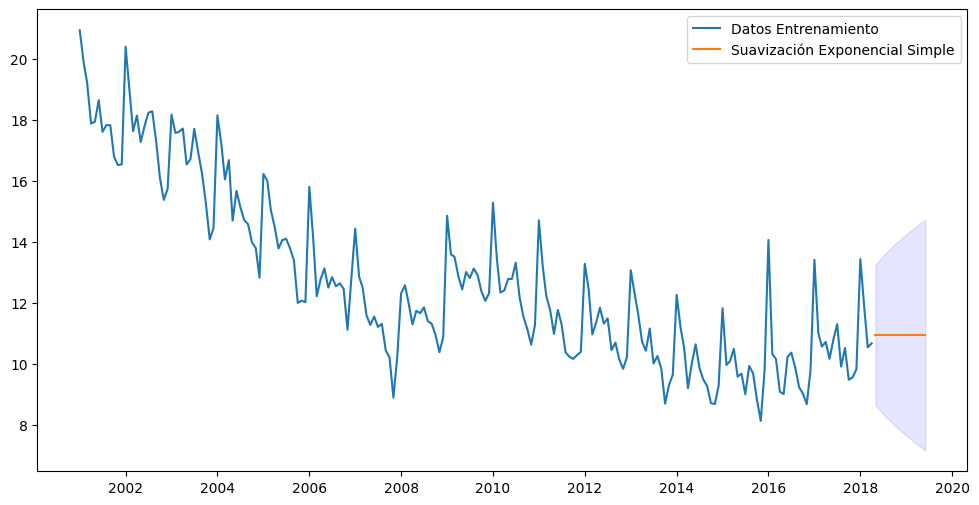

In [10]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(preds['Point_forecast'],label="Suavización Exponencial Simple")
plt.fill_between(preds.index ,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

En esta caso el α estimado es 0.3596639.Y el RMSE en la muestra de evaluación es 1.05

In [11]:
ets_result.alpha

0.35969945082396537

In [12]:
rmse = np.sqrt(mean_squared_error(test_td,point_forecast ))
print(rmse)

1.0532673907516774


### **3.2 Suavizacion Exponencial Lineal (Holt)**

In [13]:
# Build model.
ets_model = ETSModel(endog=train_td["TD_13ciudades"],error="mul",trend="mul")#,seasonal="mul" )
ets_result = ets_model.fit()

point_forecast=ets_result.forecast(14)

ci = ets_result.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds_holt = pd.concat([limits, conf_forecast], axis = 1)
preds_holt.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_holt)

            Point_forecast  lower_95   upper_95
2018-05-01       10.660588  8.631688  12.801353
2018-06-01       10.632891  8.446741  12.769005
2018-07-01       10.605266  8.402605  12.799954
2018-08-01       10.577713  8.490329  12.872343
2018-09-01       10.550231  8.563715  13.019526
2018-10-01       10.522821  8.436181  12.733728
2018-11-01       10.495481  8.255672  12.638657
2018-12-01       10.468213  8.288392  12.891170
2019-01-01       10.441016  8.257420  12.835207
2019-02-01       10.413889  8.165198  12.811793
2019-03-01       10.386833  8.185257  12.583112
2019-04-01       10.359848  8.127148  12.761234
2019-05-01       10.332932  8.072441  12.929898
2019-06-01       10.306086  8.081631  13.005774


c:\Users\dagudelo\venv_ia_generativa\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


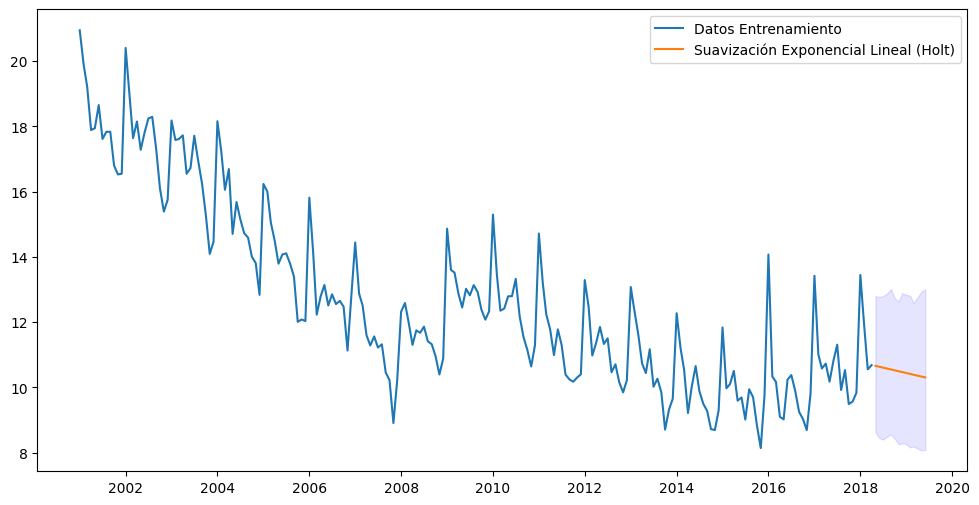

In [14]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(preds_holt['Point_forecast'],label="Suavización Exponencial Lineal (Holt)")
plt.fill_between(preds_holt.index ,preds_holt['lower_95'], preds_holt['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

En esta caso el α estimado es 0.17153975893378887 y el β estimado es 1.7153975893378887$^{-5}$. Y el RMSE en la muestra de evaluación es 1.22814498296009.

In [18]:
print(ets_result.alpha,ets_result.beta)

0.1715393694055197 1.715393694055197e-05


In [17]:
rmse_holt = np.sqrt(mean_squared_error(test_td,preds_holt['Point_forecast']))
print(rmse_holt)

1.22814498296009


### **3.3 Suavizacion Exponencial Lineal de Winters (Holt-Winters)**

In [19]:
# Build model
ets_model = ETSModel(endog=train_td["TD_13ciudades"],error="add",trend="add",seasonal="add" )
ets_result = ets_model.fit()

point_forecast=ets_result.forecast(14)

ci = ets_result.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds_hw_add = pd.concat([limits, conf_forecast], axis = 1)
preds_hw_add.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_hw_add)

            Point_forecast   lower_95   upper_95
2018-05-01       10.297375   9.251564  11.343187
2018-06-01       10.674323   9.532332  11.816314
2018-07-01       10.565101   9.334408  11.795795
2018-08-01       10.226586   8.913151  11.540021
2018-09-01        9.946359   8.555079  11.337638
2018-10-01        9.282620   7.817612  10.747628
2018-11-01        8.875131   7.339918  10.410345
2018-12-01        9.376558   7.774200  10.978917
2019-01-01       12.534203  10.867389  14.201017
2019-02-01       11.193061   9.464181  12.921941
2019-03-01       10.434222   8.645416  12.223028
2019-04-01       10.158458   8.311658  12.005258
2019-05-01        9.827779   7.924727  11.730832
2019-06-01       10.204727   8.247041  12.162413


c:\Users\dagudelo\venv_ia_generativa\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


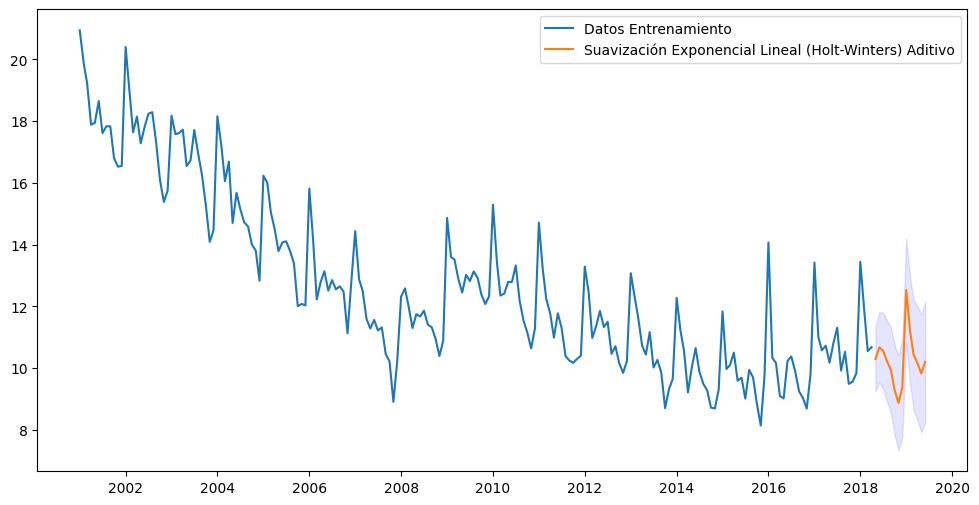

In [20]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(preds_hw_add['Point_forecast'],label="Suavización Exponencial Lineal (Holt-Winters) Aditivo")
plt.fill_between(preds_hw_add.index ,preds_hw_add['lower_95'], preds_hw_add['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

In [21]:
print(ets_result.alpha,ets_result.beta,ets_result.gamma)

0.4385788591267127 4.385788591267127e-05 5.6142114087328735e-05


In [22]:
rmse_hw_add = np.sqrt(mean_squared_error(test_td,preds_hw_add['Point_forecast']))
print(rmse_hw_add)

0.9893635516442755


In [23]:
# Build model.
ets_model = ETSModel(endog=train_td["TD_13ciudades"],error="add",trend=None,seasonal="mul" , )
ets_result = ets_model.fit()

point_forecast=ets_result.forecast(14)

ci = ets_result.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds_hw_mul = pd.concat([limits, conf_forecast], axis = 1)
preds_hw_mul.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_hw_mul)

            Point_forecast   lower_95   upper_95
2018-05-01       10.433036   9.316655  11.538286
2018-06-01       10.981856   9.782254  12.090123
2018-07-01       10.779516   9.513526  12.043866
2018-08-01       10.380956   9.012029  11.749733
2018-09-01       10.300534   8.891712  11.641392
2018-10-01        9.708898   8.196997  11.152746
2018-11-01        9.565507   7.986178  11.033846
2018-12-01       10.265135   8.571947  11.927851
2019-01-01       13.399531  11.251371  15.524083
2019-02-01       11.447407   9.579448  13.402193
2019-03-01       10.843306   8.819700  12.707781
2019-04-01       10.618172   8.634554  12.504602
2019-05-01       10.433036   8.471032  12.378804
2019-06-01       10.981856   8.710124  13.095164


c:\Users\dagudelo\venv_ia_generativa\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


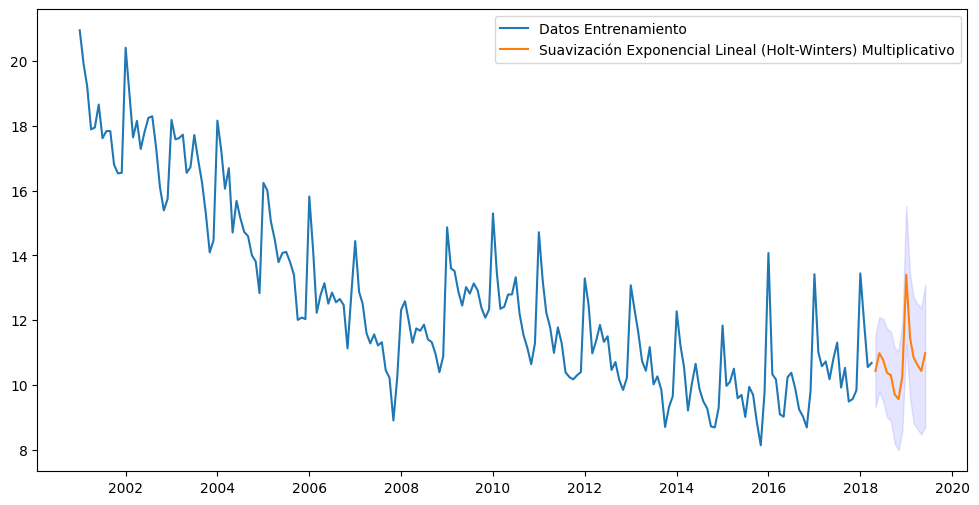

In [24]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(preds_hw_mul['Point_forecast'],label="Suavización Exponencial Lineal (Holt-Winters) Multiplicativo")
plt.fill_between(preds_hw_mul.index ,preds_hw_mul['lower_95'], preds_hw_mul['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

In [25]:
print(ets_result.alpha,ets_result.gamma)

0.43149852724451526 0.16097100344659288


In [26]:
rmse_hw_mul = np.sqrt(mean_squared_error(test_td,preds_hw_mul['Point_forecast']))
print(rmse_hw_mul)

0.601249106566862


## **4. Pronosticando con todo el data set**

In [28]:
final_model = ETSModel(endog=data["TD_13ciudades"],error="add",trend=None,seasonal="mul")
final_model_fit = final_model.fit_constrained({'smoothing_level': 0.43149852724451526,'smoothing_seasonal':0.16097100344659288})

print(final_model_fit.alpha)
print(final_model_fit.gamma)


0.43149852724451526
0.16097100344659288


c:\Users\dagudelo\venv_ia_generativa\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [29]:
point_forecast=final_model_fit.forecast(6)

ci = final_model_fit.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds_final= pd.concat([limits, conf_forecast], axis = 1)
preds_final.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_final)

            Point_forecast  lower_95   upper_95
2019-07-01       11.046643  9.942649  12.236548
2019-08-01       10.739259  9.549072  12.056542
2019-09-01       10.735391  9.482439  12.006259
2019-10-01       10.144408  8.805910  11.496054
2019-11-01        9.914408  8.612051  11.490303
2019-12-01       10.658186  9.061568  12.431729


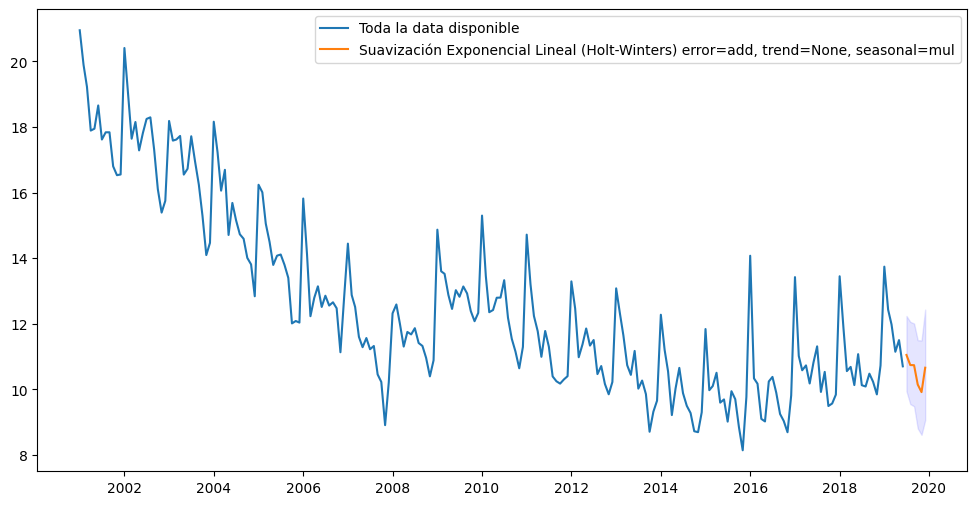

In [35]:
fig = plt.figure(figsize=(12, 6))
plt.plot(data["TD_13ciudades"],label="Toda la data disponible")
plt.plot(preds_final['Point_forecast'],label="Suavización Exponencial Lineal (Holt-Winters) error=add, trend=None, seasonal=mul")
plt.fill_between(preds_final.index ,preds_final['lower_95'], preds_final['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

## **5. Ejercicio en Clase**

Empleando la información del número de ocupados en miles de personas (Ocupados) para las 13 principales ciudades, encuentre el mejor pronóstico para los próximos 6 meses. Escriba un breve informe de máximo una página de texto que explique cómo llega a sus proyeccciones y presente las proyecciones. Aclare en el texto cuáles serían las limitaciones de sus pronósticos.